In [1]:
!pip install ultralytics

  Using cached ultralytics_thop-2.0.19-py3-none-any.whl.metadata (14 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 83.8 MB/s  0:00:006m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.7/828.7 kB 33.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 128.4 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 52.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 118.5 MB/s  0:00:00m0:00:01
Using cached ultralytics_thop-2.0.19-py3-none-any.whl (28 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [ultralytics] [ultralytics]n]-32]


In [17]:
from PIL import Image, ImageDraw, ImageFont
from ultralytics import YOLO
import numpy as np
from utils.dataloader import *
import pandas as pd
import pprint
import os
from predict import *
import random


In [18]:
DATASET_PATH = '/Users/nathan/Library/Mobile Documents/com~apple~CloudDocs/1-MIT/Spring 2026/6.S058/6.s058-Project'
yolov8_animeface = YOLO(f'{DATASET_PATH}/Model/yolov8x6_animeface.pt')
manga_name_list = get_book_list(DATASET_PATH)

In [19]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [20]:
m_name = 'Akuhamu'
page_num = 1
f'{DATASET_PATH}/Manga109/images/{m_name}/{page_num:03d}.jpg'

'/Users/nathan/Library/Mobile Documents/com~apple~CloudDocs/1-MIT/Spring 2026/6.S058/6.s058-Project/Manga109/images/Akuhamu/001.jpg'

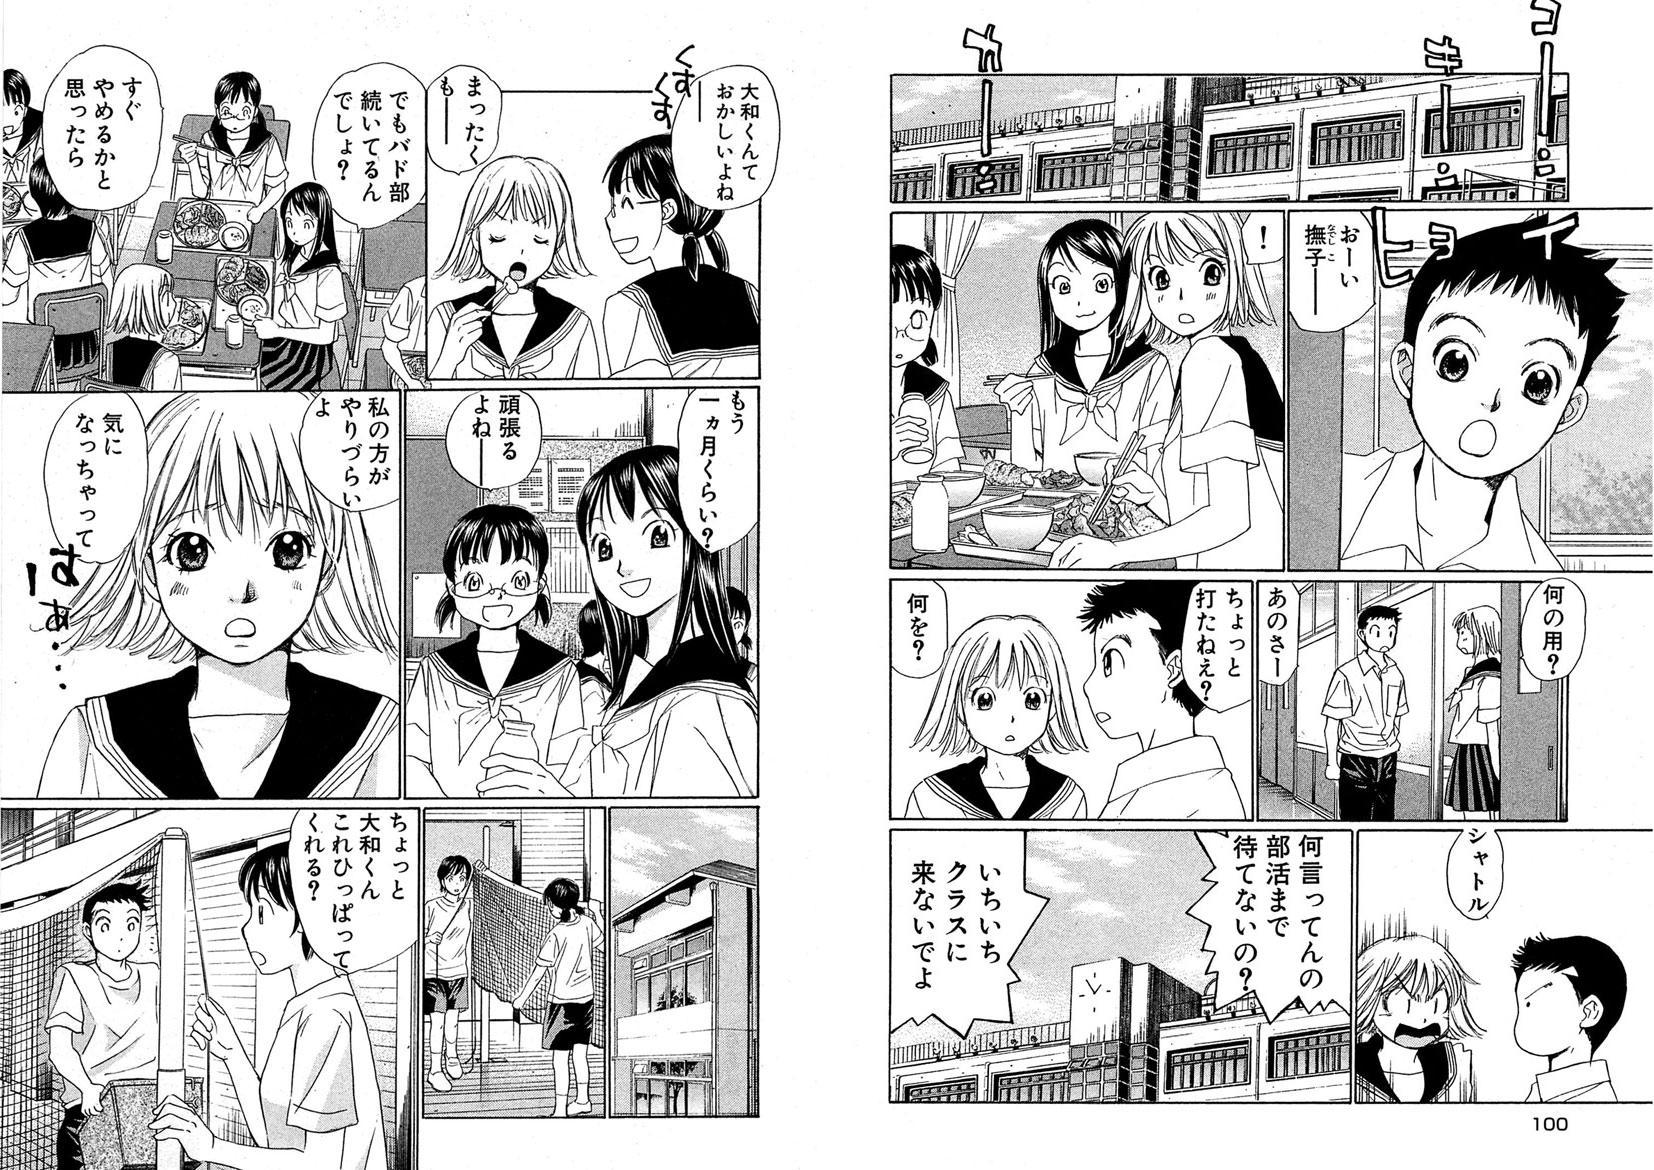

In [101]:
retrieve_page(DATASET_PATH, 'YamatoNoHane', 50)

In [22]:
def get_cropped_faces(filenames):
    """
    filenames: list of filename

    Return:
        [[file1_cropped_face1, file1_cropped_face2, ...], [file2_cropped_face1, ...], ...]
    """
    yolov8_animeface = YOLO('Model/yolov8x6_animeface.pt')
    results = yolov8_animeface.predict(filenames, save=False, conf=0.3, iou=0.5)
    bounding_boxes = get_bounding_boxes(results)
    cropped_faces = []
    for filename, boxes in zip(filenames, bounding_boxes):
        file_cropped_faces = []
        for box in boxes:
            cropped = get_cropped(filename, box)
            file_cropped_faces.append(cropped)
        cropped_faces.append(file_cropped_faces)
    return cropped_faces

# Helper Functions
def get_bounding_boxes(results):
    """
    Input
        results: list of list of detected output
    
    Return
        List of list of dicts
    """
    out = []
    for result in results:
        boxes = result.boxes
        bounding_boxes = []
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()  # top-left and bottom-right corners
            # confidence = box.conf[0].item()
            
            bound_box = np.array([[x1, y1],
                                  [x2, y2]])
            bounding_boxes.append(bound_box)
        out.append(bounding_boxes)
    return out


def get_cropped(filename, bounding_box):
    """
    Input
        filename: image file name (str)
        top_left: location of top-left corner (len-2 tuple: (x1, y1))
        bottom_right: location of bottom_right corner (len-2 tuple: (x2, y2))
    
    Return
        cropped img
    """
    img = Image.open(filename)

    top_left = bounding_box[0, :]
    bottom_right = bounding_box[1, :]
    # Pillow crop takes (left, upper, right, lower)
    cropped = img.crop((top_left[0], top_left[1], bottom_right[0], bottom_right[1]))
    return cropped

In [59]:
yolov8_animeface = YOLO('Model/yolov8x6_animeface.pt')
results = yolov8_animeface.predict(f'{DATASET_PATH}/Manga109/images/{m_name}/{page_num:03d}.jpg', save=True, conf=0.3, iou=0.5)
for result in results:
    boxes = result.boxes
    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()  # top-left and bottom-right corners
        confidence = box.conf[0].item()
        
        print(f"Face detected:")
        print(f"  Top-left:     ({x1:.1f}, {y1:.1f})")
        print(f"  Bottom-right: ({x2:.1f}, {y2:.1f})")
        print(f"  Width:        {x2 - x1:.1f}px")
        print(f"  Height:       {y2 - y1:.1f}px")
        print(f"  Confidence:   {confidence:.2f}")
        print()


image 1/1 /Users/nathan/Library/Mobile Documents/com~apple~CloudDocs/1-MIT/Spring 2026/6.S058/6.s058-Project/Manga109/images/Akuhamu/001.jpg: 960x1280 4 faces, 1886.0ms
Speed: 19.3ms preprocess, 1886.0ms inference, 13.1ms postprocess per image at shape (1, 3, 960, 1280)
Results saved to /Users/nathan/Library/Mobile Documents/com~apple~CloudDocs/1-MIT/Spring 2026/6.S058/6.s058-Project/runs/detect/predict
Face detected:
  Top-left:     (474.8, 353.7)
  Bottom-right: (669.0, 509.7)
  Width:        194.2px
  Height:       156.0px
  Confidence:   0.89

Face detected:
  Top-left:     (216.8, 149.7)
  Bottom-right: (304.7, 225.5)
  Width:        87.9px
  Height:       75.8px
  Confidence:   0.83

Face detected:
  Top-left:     (229.2, 652.1)
  Bottom-right: (384.1, 851.3)
  Width:        154.9px
  Height:       199.2px
  Confidence:   0.82

Face detected:
  Top-left:     (569.8, 144.9)
  Bottom-right: (640.5, 204.7)
  Width:        70.6px
  Height:       59.8px
  Confidence:   0.57




0: 960x1280 4 faces, 55.6ms
Speed: 38.6ms preprocess, 55.6ms inference, 50.7ms postprocess per image at shape (1, 3, 960, 1280)


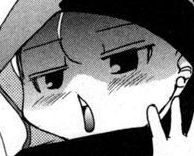

In [7]:
get_cropped_faces([f'{DATASET_PATH}/Manga109/images/{m_name}/{page_num:03d}.jpg'])[0][0]

In [23]:
def compute_iou(box1, box2):
    """
    box1, box2: (xmin, ymin, xmax, ymax)
    """
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0.0


def get_avg_iou(detected_boxes, annotated_boxes, iou_threshold=0.5):
    matched_annotations = set()
    ious = []

    for det in detected_boxes:
        best_iou = 0
        best_idx = -1

        for i, ann in enumerate(annotated_boxes):
            if i in matched_annotations:
                continue
            iou = compute_iou(det, ann)
            if iou > best_iou:
                best_iou = iou
                best_idx = i

        if best_iou >= iou_threshold and best_idx != -1:
            matched_annotations.add(best_idx)
            ious.append(best_iou)

    # penalize missed annotations
    fn = len(annotated_boxes) - len(matched_annotations)
    ious += [0.0] * fn

    return np.mean(ious) if ious else 0.0

In [24]:
def compute_accuracy(path, manga_name, device='cuda', batch_size=8):
    annotations = annotation_loader(path, manga_name)
    ann_pages = get_location(annotations, 'face')

    yolov8_animeface = YOLO('Model/yolov8x6_animeface.pt')

    filenames = []
    ann_boxes = []
    for page_num in ann_pages:
        filenames.append(f'{path}/Manga109/images/{manga_name}/{page_num:03d}.jpg')
        ann_boxes.append([face['position'] for face in ann_pages[page_num]])

    page_ious = []
    for i in range(0, len(filenames), batch_size):
        batch_files = filenames[i:i+batch_size]
        batch_ann = ann_boxes[i:i+batch_size]

        results = yolov8_animeface.predict(batch_files, save=False, conf=0.3, iou=0.5, device=device)

        for result, ann in zip(results, batch_ann):
            pred_boxes = [box.xyxy[0].tolist() for box in result.boxes]
            iou = get_avg_iou(pred_boxes, ann, iou_threshold=0.5)
            page_ious.append(iou)

    return np.mean(page_ious) if page_ious else 0.0

In [ ]:
ious = []
for manga_name in manga_name_list:
    print(f'Processing {manga_name}...')
    ious.append(compute_accuracy(DATASET_PATH, manga_name, device=device))
    print(f'  IoU: {ious[-1]:.4f}')

df = pd.DataFrame({'IOU': ious}, index=manga_name_list)
df.to_csv('YOLO_accuracy.csv', index=True)
print(df)

In [6]:
compute_accuracy(DATASET_PATH, m_name)


0: 960x1280 (no detections), 5209.3ms
1: 960x1280 4 faces, 5209.3ms
2: 960x1280 6 faces, 5209.3ms
3: 960x1280 5 faces, 5209.3ms
4: 960x1280 5 faces, 5209.3ms
5: 960x1280 10 faces, 5209.3ms
6: 960x1280 13 faces, 5209.3ms
7: 960x1280 11 faces, 5209.3ms
8: 960x1280 11 faces, 5209.3ms
9: 960x1280 2 faces, 5209.3ms
10: 960x1280 11 faces, 5209.3ms
11: 960x1280 7 faces, 5209.3ms
12: 960x1280 2 faces, 5209.3ms
13: 960x1280 7 faces, 5209.3ms
14: 960x1280 2 faces, 5209.3ms
15: 960x1280 4 faces, 5209.3ms
16: 960x1280 12 faces, 5209.3ms
17: 960x1280 6 faces, 5209.3ms
18: 960x1280 5 faces, 5209.3ms
19: 960x1280 20 faces, 5209.3ms
20: 960x1280 13 faces, 5209.3ms
21: 960x1280 2 faces, 5209.3ms
22: 960x1280 4 faces, 5209.3ms
23: 960x1280 4 faces, 5209.3ms
24: 960x1280 11 faces, 5209.3ms
25: 960x1280 17 faces, 5209.3ms
26: 960x1280 5 faces, 5209.3ms
27: 960x1280 4 faces, 5209.3ms
28: 960x1280 7 faces, 5209.3ms
29: 960x1280 5 faces, 5209.3ms
30: 960x1280 4 faces, 5209.3ms
31: 960x1280 13 faces, 5209.3m

np.float64(0.22040985069010255)

In [25]:
def get_paired_pred_boxes_labels(detected_boxes, annotations, page_num, iou_threshold=0.5):
    annotated_faces = get_location(annotations, 'face')[page_num]
    annotated_boxes = [face['position'] for face in annotated_faces]
    
    # compute all iou pairs
    all_pairs = []
    for det_idx, det in enumerate(detected_boxes):
        for ann_idx, ann in enumerate(annotated_boxes):
            iou = compute_iou(det, ann)
            if iou >= iou_threshold:
                all_pairs.append((iou, det_idx, ann_idx))
    
    # sort by iou descending — greedily match best pairs first
    all_pairs.sort(reverse=True)
    
    matched_dets = set()
    matched_anns = set()
    results = []
    
    for iou, det_idx, ann_idx in all_pairs:
        if det_idx in matched_dets or ann_idx in matched_anns:
            continue
        char_id = annotated_faces[ann_idx]['character']
        results.append((detected_boxes[det_idx], char_id, iou))
        matched_dets.add(det_idx)
        matched_anns.add(ann_idx)
    
    return results

In [120]:
# Visualization
def draw_face_boxes(image_path, boxes, output_path="output.jpg",
                   color=(255, 0, 0), line_width=2, labels=None, font_size=20, num_line=2):
    """
    Draw face bounding boxes on an image.

    Args:
        image_path  : Path to input image
        boxes       : List of (xmin, ymin, xmax, ymax)
        output_path : Where to save the result
        color       : Box color in (R, G, B)
        line_width  : Thickness of box outline
    """
    image = Image.open(image_path).convert("RGB")
    draw  = ImageDraw.Draw(image)
    # font = ImageFont.load_default(size=font_size)
    font = ImageFont.truetype("/System/Library/Fonts/Helvetica.ttc", font_size)

    for i, (xmin, ymin, xmax, ymax) in enumerate(boxes):
        draw.rectangle([xmin, ymin, xmax, ymax], outline=color, width=line_width)
        if labels and i < len(labels):
            text = str(labels[i])
            bbox = draw.textbbox((xmin, ymin - num_line*font_size - 2), text, font=font)
            # filled background
            draw.rectangle(bbox, fill=color)
            # white text
            draw.text((xmin, ymin - num_line*font_size - 2), text, fill=(255, 255, 255), font=font)

    image.save(output_path)
    print(f"Saved → {output_path}")
    return image

def overlay_ann_det(path, manga_name, page_num):
    annotations = annotation_loader(path, manga_name)

    result = yolov8_animeface.predict([f'{path}/Manga109/images/{manga_name}/{page_num:03d}.jpg'],
    save=False, conf=0.3, iou=0.5, device=device, verbose=False)[0]

    os.makedirs(f'{path}/yolo_vis/{manga_name}', exist_ok=True)
    result.save(filename=f'{path}/yolo_vis/{manga_name}/{page_num:03d}.jpg')

    pred_boxes = [box.xyxy[0].tolist() for box in result.boxes] # to return

    # Overlay annotations
    annotated_faces = get_location(annotations, 'face')[page_num]
    annotated_boxes = [face['position'] for face in annotated_faces]

    draw_face_boxes(f'{path}/yolo_vis/{manga_name}/{page_num:03d}.jpg', annotated_boxes, f'{path}/yolo_vis/{manga_name}/{page_num:03d}_annotated_detected.jpg')

    return pred_boxes, annotations

In [ ]:
def train_test_split_data(data_dict, train_ratio=0.8, shuffle=True, random_seed=None):
    '''
    Split character image data into training and test sets with optional shuffling
    Arguments
        data_dict: 
    '''
    if random_seed is not None:
        random.seed(random_seed)
    
    train_data = []
    train_label = []
    test_data = []
    test_label = []
    
    for char_id, images in data_dict.items():
        # Shuffle images for this character if requested
        char_images = images.copy()
        if shuffle:
            random.shuffle(char_images)
        
        # Calculate split point
        split_idx = int(len(char_images) * train_ratio)
        
        # Split and extend lists
        train_data.extend(char_images[:split_idx])
        train_label.extend([char_id] * split_idx)
        
        test_data.extend(char_images[split_idx:])
        test_label.extend([char_id] * (len(char_images) - split_idx))
    
    # Final shuffle of all data
    if shuffle:
        combined_train = list(zip(train_data, train_label))
        random.shuffle(combined_train)
        train_data, train_label = zip(*combined_train)
        train_data, train_label = list(train_data), list(train_label)
        
        combined_test = list(zip(test_data, test_label))
        random.shuffle(combined_test)
        test_data, test_label = zip(*combined_test)
        test_data, test_label = list(test_data), list(test_label)
    
    return train_data, train_label, test_data, test_label

Saved → /Users/nathan/Library/Mobile Documents/com~apple~CloudDocs/1-MIT/Spring 2026/6.S058/6.s058-Project/yolo_vis/YamatoNoHane/050_annotated_detected.jpg
Saved → /Users/nathan/Library/Mobile Documents/com~apple~CloudDocs/1-MIT/Spring 2026/6.S058/6.s058-Project/yolo_vis/YamatoNoHane/050_matched_detected.jpg
Saved → /Users/nathan/Library/Mobile Documents/com~apple~CloudDocs/1-MIT/Spring 2026/6.S058/6.s058-Project/yolo_vis/YamatoNoHane/050_annotated_matched_detected.jpg


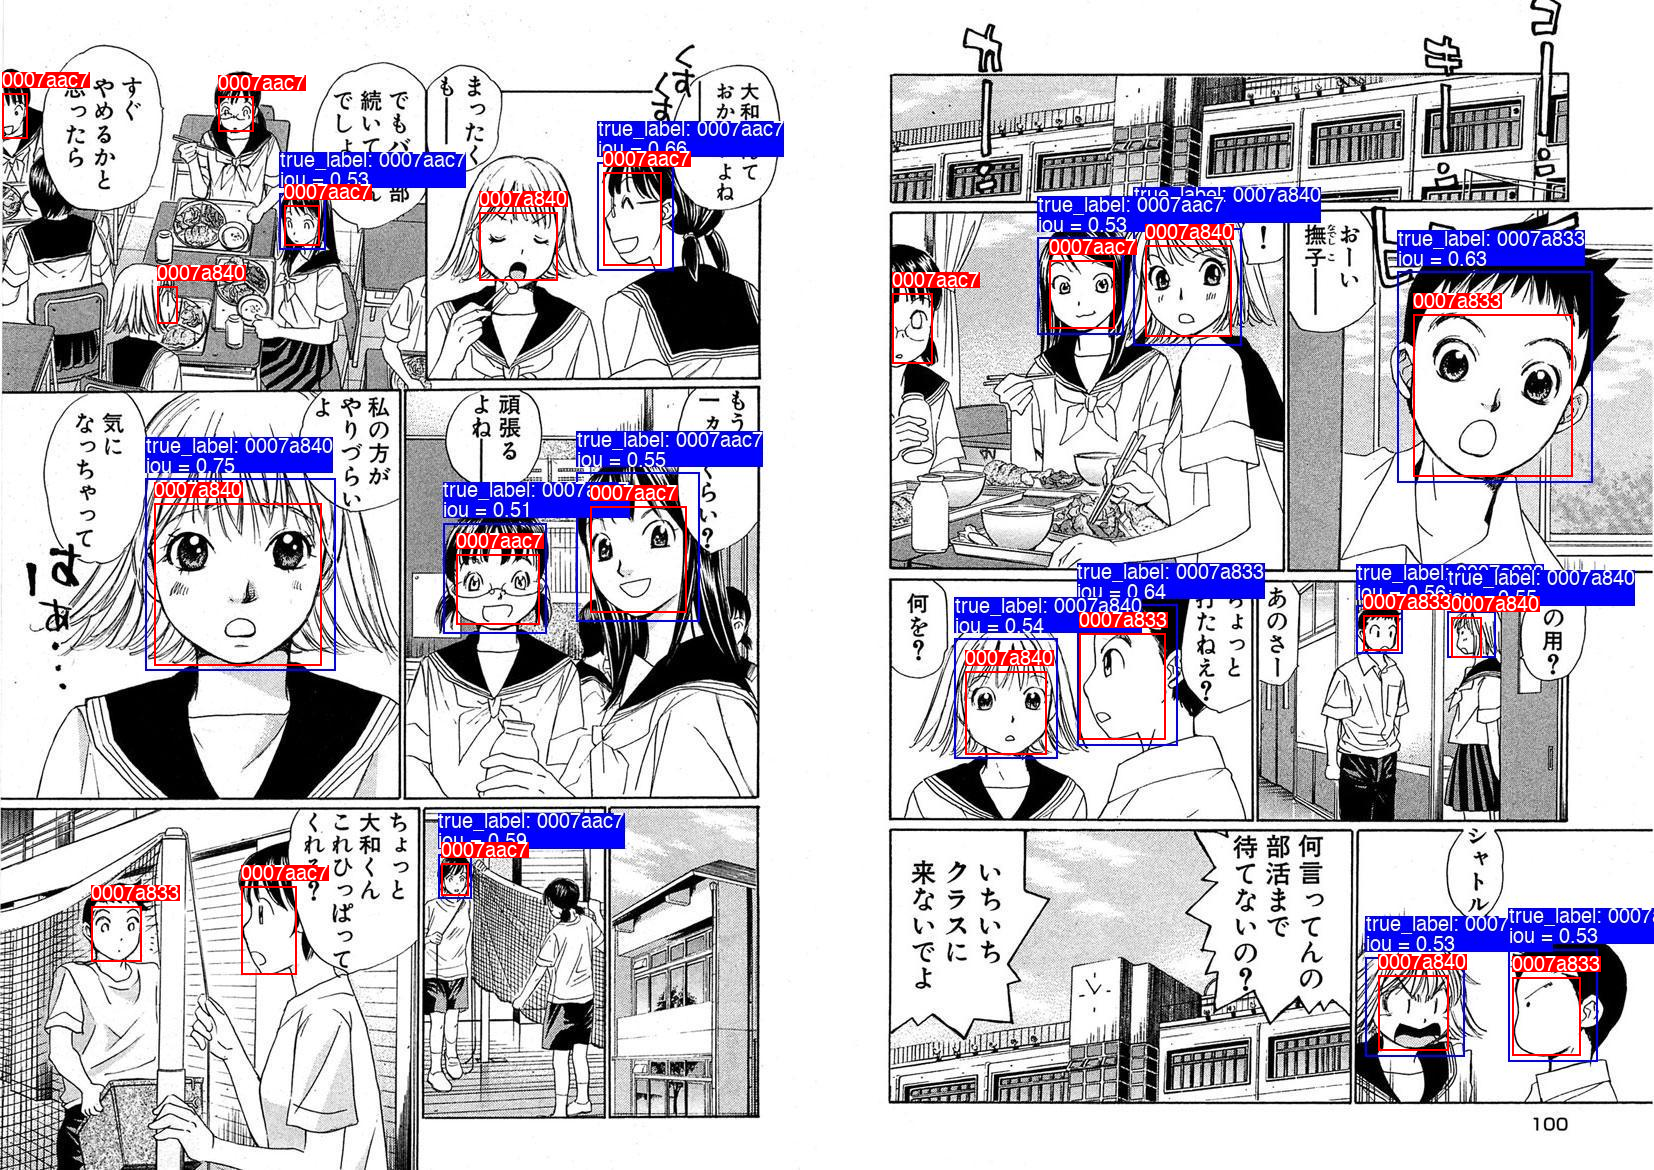

In [121]:
manga_name = "YamatoNoHane"
page_num = 50

pred_boxes, annotations = overlay_ann_det(DATASET_PATH, manga_name, page_num)

matched_pred_boxes = []
labels = []
paired_pred_boxes_labels = get_paired_pred_boxes_labels(pred_boxes, annotations, page_num, iou_threshold=0.5)
for pred_box, char_id, iou in paired_pred_boxes_labels:
    matched_pred_boxes.append(pred_box)
    labels.append(f'true_label: {char_id}\niou = {iou:.2f}')

draw_face_boxes(f'{DATASET_PATH}/Manga109/images/{manga_name}/{page_num:03d}.jpg', matched_pred_boxes, f'{DATASET_PATH}/yolo_vis/{manga_name}/{page_num:03d}_matched_detected.jpg', color=(0, 0, 255), labels=labels, font_size=20)

annotated_faces = get_location(annotations, 'face')[page_num]
annotated_boxes = [face['position'] for face in annotated_faces]
draw_face_boxes(f'{DATASET_PATH}/yolo_vis/{manga_name}/{page_num:03d}_matched_detected.jpg', annotated_boxes, f'{DATASET_PATH}/yolo_vis/{manga_name}/{page_num:03d}_annotated_matched_detected.jpg', labels=[annotated_faces[i]['character'] for i in range(len(annotated_faces))], num_line=1)

In [122]:
for elt in annotations['book']['characters']['character']:
    if elt['@id'] == '0007aac7':
        print(elt['@name'])

_Other


In [29]:
model = SimCLRModel()
model.load_state_dict(torch.load(f'simclr-2.pt', weights_only=True, map_location=torch.device('cpu')))

<All keys matched successfully>

In [103]:
# Preparing training dataset
d = create_data(DATASET_PATH, annotations, (112, 112))
char_dict = {v['id']: v['face_imgs'] for v in d.values()}
train_data, train_label, _, _ = train_test_split_data(char_dict, train_ratio=0.2, shuffle=True)

In [104]:
# Embedding training dataset
to_tensor = transforms.ToTensor()

train_tensors = [to_tensor(im) for im in train_data]
train_tensor_stack = torch.stack(train_tensors)

embedded_training_vectors = model(train_tensor_stack)

In [105]:
# Embedding page of interest
new_data = []
for position in matched_pred_boxes:
    new_data.append(retrieve_page(DATASET_PATH, manga_name, page_num, position, target_size=(112,112)))

new_data_tensors = [to_tensor(im) for im in new_data]
new_data_tensor_stack = torch.stack(new_data_tensors)

embedded_new_data_vectors = model(new_data_tensor_stack)

In [106]:
embedded_new_data_vectors = embedded_new_data_vectors.detach().numpy()
embedded_training_vectors =embedded_training_vectors.detach().numpy()
predictions = knn_classify(embedded_new_data_vectors, embedded_training_vectors, train_label, 8).tolist()

In [ ]:
prediction_labels = [f'true_label: {elt[1]}\npredicted_label = {predictions[i]}' for i, elt in enumerate(paired_pred_boxes_labels)]

draw_face_boxes(f'{DATASET_PATH}/Manga109/images/{manga_name}/{page_num:03d}.jpg', matched_pred_boxes, f'{DATASET_PATH}/yolo_vis/{manga_name}/{page_num:03d}_predicted_matched_detected.jpg', color=(0, 0, 255), labels=prediction_labels, font_size=10)

draw_face_boxes(f'{DATASET_PATH}/yolo_vis/{manga_name}/{page_num:03d}_predicted_matched_detected.jpg', annotated_boxes, f'{DATASET_PATH}/yolo_vis/{manga_name}/{page_num:03d}_annotated_predicted_matched_detected.jpg')